In [ ]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [28]:
pd.set_option('display.max_columns', None)

In [69]:
df = pd.read_csv('..\Dataset\Telco_Customer_Churn_Cleaned.csv')

## Data Preparation

In [70]:
df = df.iloc[:, 1:len(df.columns)]

In [71]:
df['gender'] = df['gender'].map({'Female' : 1, 'Male' : 0}).astype(float)
df[['senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines',  'online_security', 'online_backup', 'device_protection', 'tech_support', 	'streaming_tv', 'streaming_movies', 'paperless_billing', 'churn']] = df[['senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines',  'online_security', 'online_backup', 'device_protection', 'tech_support', 	'streaming_tv', 'streaming_movies', 'paperless_billing', 'churn']].replace({'Yes' : 1, 'No' : 0}).astype(float)

C:\Users\Asus\AppData\Local\Temp\ipykernel_19584\3361212788.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines',  'online_security', 'online_backup', 'device_protection', 'tech_support', 	'streaming_tv', 'streaming_movies', 'paperless_billing', 'churn']] = df[['senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines',  'online_security', 'online_backup', 'device_protection', 'tech_support', 	'streaming_tv', 'streaming_movies', 'paperless_billing', 'churn']].replace({'Yes' : 1, 'No' : 0}).astype(float)


In [73]:
category_colls = ['internet_service', 'contract', 'payment_method']

category_encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = category_encoder.fit_transform(df[category_colls])
df_encoded = pd.DataFrame(encoded, columns=category_encoder.get_feature_names_out(category_colls))
df_encoded = pd.concat([df.drop(columns=category_colls), df_encoded],axis=1)
df_encoded

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,paperless_billing,monthly_charges,total_charges,churn,expected_charges,diff_charges,total_services,internet_service_Fiber optic,internet_service_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,1.0,0.0,1.0,0.0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,29.85,29.85,0.0,29.85,0.00,2,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,34,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,56.95,1889.50,0.0,1936.30,-46.80,4,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,2,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,53.85,108.15,1.0,107.70,0.45,4,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,45,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,42.30,1840.75,0.0,1903.50,-62.75,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,70.70,151.65,1.0,141.40,10.25,2,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,0.0,1.0,1.0,24,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,84.80,1990.50,0.0,2035.20,-44.70,8,0.0,0.0,1.0,0.0,0.0,0.0,1.0
7039,1.0,0.0,1.0,1.0,72,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,103.20,7362.90,0.0,7430.40,-67.50,7,1.0,0.0,1.0,0.0,1.0,0.0,0.0
7040,1.0,0.0,1.0,1.0,11,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,29.60,346.45,0.0,325.60,20.85,2,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7041,0.0,1.0,1.0,0.0,4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,74.40,306.60,1.0,297.60,9.00,3,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## Data Preprocessing

In [77]:
x = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

In [79]:
from sklearn.model_selection import train_test_split

In [80]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

## Logistic Regression 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [116]:
lr_model = LogisticRegression(max_iter=1000, solver='liblinear')
lr_model.fit(x_train, y_train)
y_pred = lr_model.predict(x_test)

In [117]:
print(f"""Classification Report
      {classification_report(y_test, y_pred)}
"""
)

Classification Report
                    precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1035
         1.0       0.66      0.54      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409




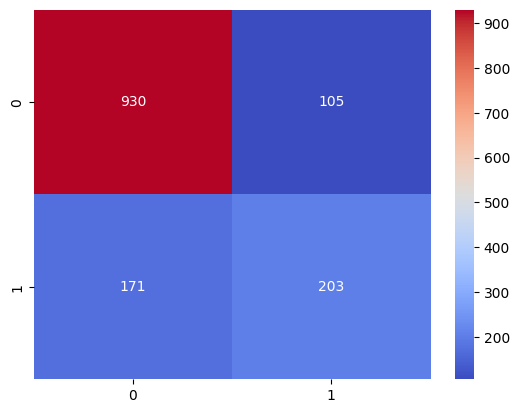

In [118]:
cf = confusion_matrix(y_test, y_pred)
sns.heatmap(cf, annot=True, fmt="d", cmap="coolwarm") 
plt.show()

## Analyze Features Importance using Logistic Regression 

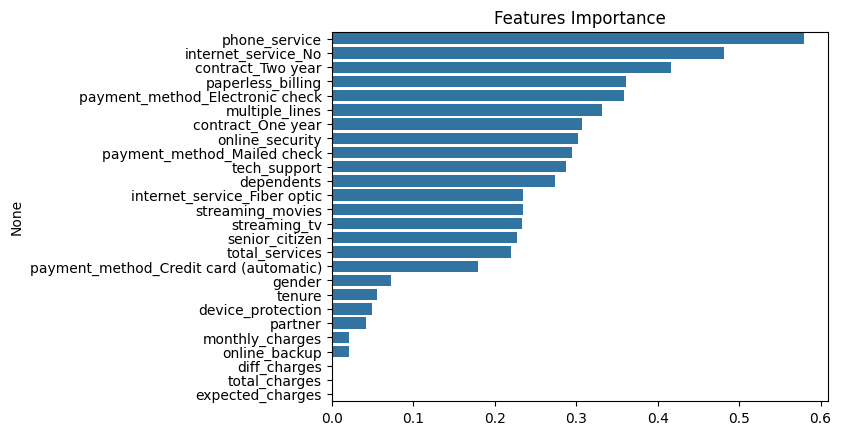

In [120]:
lr_importance = lr_model.coef_[0]
lr_feature_importance = np.abs(lr_importance)

sorted_idx = np.argsort(lr_feature_importance)[::-1]
sorted_features = x.columns[sorted_idx]
sorted_importance = lr_feature_importance[sorted_idx]

sns.barplot(x=sorted_importance, y=sorted_features)
plt.title('Features Importance') 
plt.show()

**Insights:**

- Phone service and not subscribing to internet service are the most influential features in determining churn.

- The two-year contract has the strongest impact compared to other contract types, which is consistent with the results from the SVC model.

- In the context of payment methods, paperless billing, electronic check, and mailed check are more associated with churn compared to automatic credit card payments.

- In the context of pricing, the influence is lower than that of services, indicating that service-related factors play a more important role than cost in driving churn.

## SVC 

In [90]:
svc_model = SVC(kernel='linear', C=1.0)
svc_model.fit(x_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [93]:
y_pred_svc = svc_model.predict(x_test)

In [94]:
print(f"""Classification Report
      {classification_report(y_test, y_pred_svc)}
"""
)

Classification Report
                    precision    recall  f1-score   support

         0.0       0.81      0.93      0.87      1035
         1.0       0.68      0.41      0.51       374

    accuracy                           0.79      1409
   macro avg       0.74      0.67      0.69      1409
weighted avg       0.78      0.79      0.77      1409




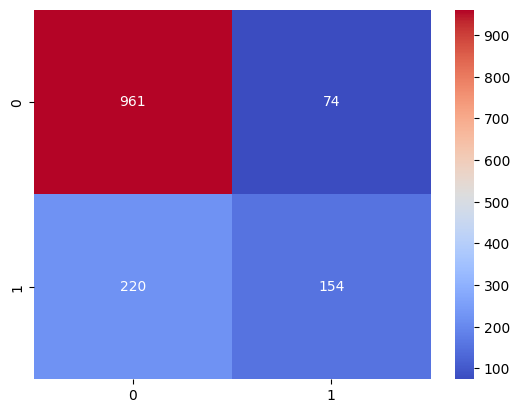

In [95]:
cf = confusion_matrix(y_test, y_pred_svc)
sns.heatmap(cf, annot=True, fmt="d", cmap="coolwarm") 
plt.show()

## Analyze Features Importance using SVC 

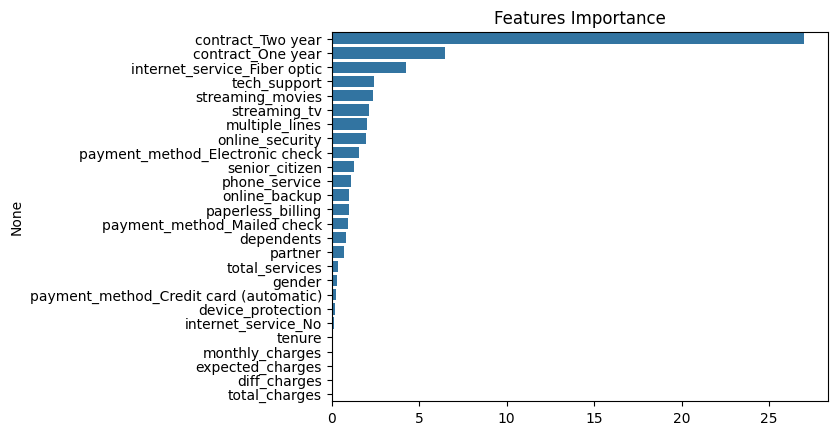

In [121]:
svc_importance = svc_model.coef_[0]
svc_feature_importance = np.abs(svc_importance)

sorted_idx = np.argsort(svc_feature_importance)[::-1]
sorted_features = x.columns[sorted_idx]
sorted_importance = svc_feature_importance[sorted_idx]

sns.barplot(x=sorted_importance, y=sorted_features)
plt.title('Features Importance') 
plt.show()

**Insights :** 

- The two-year contract plays the most significant role in determining churn compared to the one-year contract.

- Fiber optic internet service shows a strong influence, followed by additional services that can affect customer loyalty.

- Payment methods such as electronic check and mailed check have an impact, but their influence is relatively low.

- Demographic features such as senior citizen, gender, partner, and dependents have a minor influence, indicating they are not strong determinants of churn.

- Cost-related features including monthly charges, total charges, difference charges, and expected charges show the least impact, suggesting that pricing is not the main driver of churn compared to contracts and services offered.